In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

> 기본적인 엑셀 데이터 불러오기

In [5]:
view_history = pd.read_excel("../Dataset/View_History.xlsx")
view_history.head()

,USER_ID,MOVIE_ID,DURATION,WATCH_DAY,WATCH_SEQ
0,0,4243,1,20210314,1
1,0,4243,111,20210314,2
2,0,1860,101,20210319,1
3,0,2170,1,20210325,1
4,0,6031,100,20210326,1


> 각 유저별로 단위기간(구독기간)동안 몇 분간 시청했는지

,DURATION
USER_ID,
0,510
1,124
2,293
4,309
5,3
...,...
19871,562
19872,1241
19873,1


count            14892.0
mean               317.1
std                327.5
min                  1.0
25%                 98.0
50%                225.0
75%                436.0
max               4419.0
upper_whisker      943.0
Name: DURATION, dtype: float64

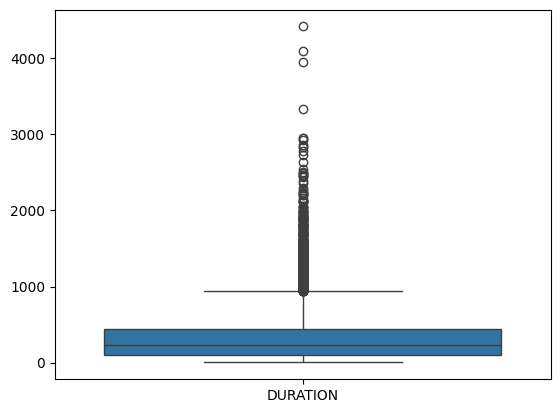

In [36]:
user_duration_group = (
	view_history.groupby("USER_ID")["DURATION"]
	.sum()
	# .sort_values(ascending=False) DURATION 기준 오름차순 정렬 하고 싶다면
)

# Dataframe
df_user_duration_group = pd.DataFrame(user_duration_group)
display(df_user_duration_group)

desc = df_user_duration_group["DURATION"].describe()
desc["upper_whisker"] = desc["75%"] + 1.5 * (desc["75%"] - desc["25%"])
display(desc.round(1))

# Boxplot
boxplot_user_duration_group = sns.boxplot(df_user_duration_group)

> 각 유저별로 단위기간(구독기간) 동안 몇 번이나 접속했는가

In [45]:
user_visit_groupby = view_history.groupby("USER_ID")["WATCH_DAY"].nunique()
df_user_visit_groupby = pd.DataFrame(user_visit_groupby)
display(df_user_visit_groupby)

,WATCH_DAY
USER_ID,
0,5
1,1
2,4
4,4
5,1
...,...
19871,8
19872,7
19873,1


> 각 유저별로 몇 개의 영화를 얼마나 시청했는지

In [ ]:
user_movie_groupby = view_history.groupby(["USER_ID", "MOVIE_ID"])["DURATION"].sum()

df_user_movie_groupby = pd.DataFrame(user_movie_groupby)
display(df_user_movie_groupby)

DURATION
USER_ID MOVIE_ID          
0       1860           101
        2170            94
        4243           112
        6031           200
        12495            3
...                    ...
19873   12759            1
19874   9267             1
        12298            1
        14489            2
19875   1037             1

[75936 rows x 1 columns]

> 구독 해놓고 한 번이라도 본 사람 vs 한 번도 접속 안 한 사람

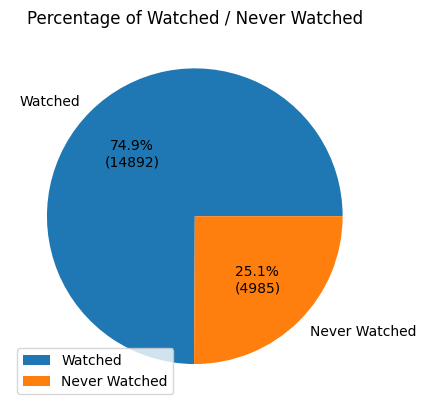

In [48]:
user_duration = view_history.groupby("USER_ID")["DURATION"].sum().reset_index()
watched = len(user_duration)
not_watched = len(pd.read_excel("../Dataset/User_Mapping.xlsx")) - watched

values = [watched, not_watched]

def make_label(pct):
    count = int(round(pct/100 * sum(values)))
    return f"{pct:.1f}%\n({count})"

plt.pie(values, labels=["Watched", "Never Watched"], autopct=make_label)
plt.legend(loc = "lower left")
plt.title("Percentage of Watched / Never Watched")
plt.show()

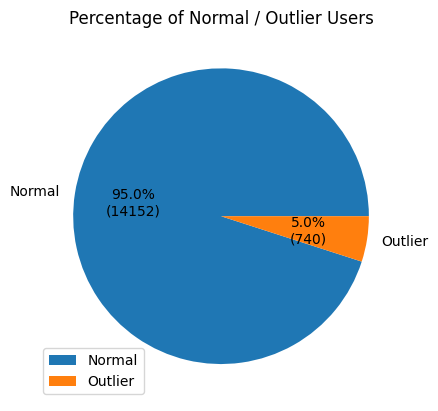

In [49]:
QR1 = int(user_duration["DURATION"].quantile(0.25))
QR3 = int(user_duration["DURATION"].quantile(0.75))
IQR = QR3-QR1
lower = QR1 - 1.5 * IQR
upper = QR3 + 1.5 * IQR
normal = ((user_duration["DURATION"] >= lower) & (user_duration["DURATION"] <= upper)).sum()
high_outlier = (user_duration["DURATION"] > upper).sum()
values = [normal, high_outlier]

def make_label(pct):
    count = int(round(pct / 100 * sum(values)))
    return f"{pct:.1f}%\n({count})"

plt.pie(values, labels=["Normal", "Outlier"], autopct=make_label)
plt.legend(loc="lower left")
plt.title("Percentage of Normal / Outlier Users")
plt.show()
